In [ ]:
from slac_model.models.cu import get_cu_hxr_bmad_va

va = get_cu_hxr_bmad_va(end_element="TD11")

### Get rmats

In [ ]:
# simulate scan
import time

import numpy as np
from lume_bmad.utils import rmat_get

va = get_cu_hxr_bmad_va(start_element="QE01#1", end_element="OTR2")
values = np.linspace(-10, 0, 10)

matricies = []
start_time = time.time()
for ele in values:
    va.set({"QUAD:IN20:525:BCTRL": ele})
    matricies.append(rmat_get(va.tao, "QE01#1", "OTR2"))

print(f"Time for {len(values)} calls: {time.time() - start_time:.2f} seconds")

print(matricies[-1])

### Get twiss values

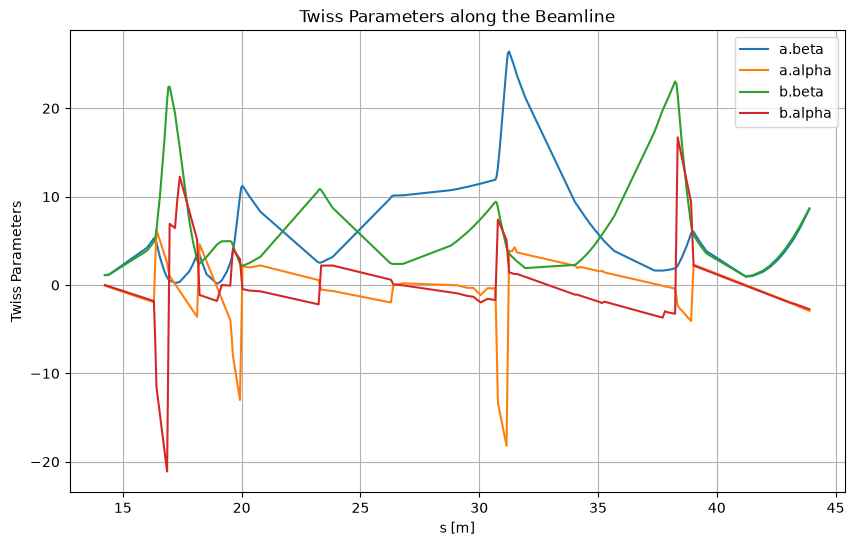

In [6]:
import matplotlib.pyplot as plt

va = get_cu_hxr_bmad_va(end_element="TD11")

# get twiss values from the virtual accelerator
twiss_values = va.get(["s_ele","a.beta","a.alpha", "b.beta", "b.alpha"])

# plot the twiss values
plt.figure(figsize=(10, 6))
plt.plot(twiss_values["s_ele"], twiss_values["a.beta"], label="a.beta")
plt.plot(twiss_values["s_ele"], twiss_values["a.alpha"], label="a.alpha")
plt.plot(twiss_values["s_ele"], twiss_values["b.beta"], label="b.beta")
plt.plot(twiss_values["s_ele"], twiss_values["b.alpha"], label="b.alpha")
plt.xlabel("s [m]")
plt.ylabel("Twiss Parameters")
plt.title("Twiss Parameters along the Beamline")
plt.legend()
plt.grid(True)
plt.show()
